In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
from sklearn.preprocessing import StandardScaler

RFM_Data=pd.read_csv('RFM_Data.csv')
# 複製原始資料
rfmn = RFM_Data.copy()

# 使用 StandardScaler 進行正規化
scaler = StandardScaler()
rfmn[['R', 'F', 'M']] = scaler.fit_transform(rfmn[['R', 'F', 'M']])

# 檢視正規化後的資料
print(rfmn.head())

  Customer         F         M         R
0    A0350  1.347566  0.710046 -0.661105
1    A0351 -0.753785 -0.566299 -0.536734
2    A0352  0.130994  0.525794 -0.572268
3    A0353  0.130994 -0.194379 -0.394595
4    A0354 -0.753785 -0.869289 -0.270224


In [16]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# 1. 執行正規化處理並命名為 nrfm
nrfm = RFM_Data.copy()
scaler = MinMaxScaler()
nrfm[['R', 'F', 'M']] = scaler.fit_transform(nrfm[['R', 'F', 'M']])

# 2. 使用 K-means 進行分群，設定群數 K = 4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
nrfm['Cluster'] = kmeans.fit_transform(nrfm[['R', 'F', 'M']]).argmin(axis=1) # 或是直接使用 labels_
nrfm['Cluster'] = kmeans.labels_

# 同時將群組標籤加回原始的 RFM_Data，方便後續觀察真實數值
RFM_Data['Cluster'] = kmeans.labels_

# 顯示分群後的結果
display(nrfm.head())

,Customer,F,M,R,Cluster
0,A0350,0.631579,0.376563,0.024523,1
1,A0351,0.131579,0.127866,0.043597,2
2,A0352,0.342105,0.340662,0.038147,1
3,A0353,0.342105,0.200335,0.065395,1
4,A0354,0.131579,0.068827,0.084469,2


In [17]:
# 統計各群的資料筆數
print(nrfm['Cluster'].value_counts().sort_index())

Cluster
0     76
1    221
2    321
3    114
Name: count, dtype: int64


In [22]:
import pandas as pd

# 1. 讀取已改名的原始檔案 RFM_Data.csv 作為 df
df = pd.read_csv('RFM_Data.csv')

# 2. 建立客戶與群組的對照表
cluster_mapping = RFM_Data[['Customer', 'Cluster']]

# 3. 將分群標籤 Cluster 合併回原始資料 df
# 這裡的客戶識別碼為 'Customer'
df = df.merge(cluster_mapping, on='Customer', how='left')

print("已成功將 Cluster 分組標籤合併回原始資料 df！")
display(df.head())

已成功將 Cluster 分組標籤合併回原始資料 df！


,Customer,F,M,R,Cluster
0,A0350,25,51238.11440,9,1
1,A0351,6,17890.31200,16,2
2,A0352,14,46424.03852,14,1
3,A0353,14,27607.68636,24,1
4,A0354,6,9973.92064,31,2


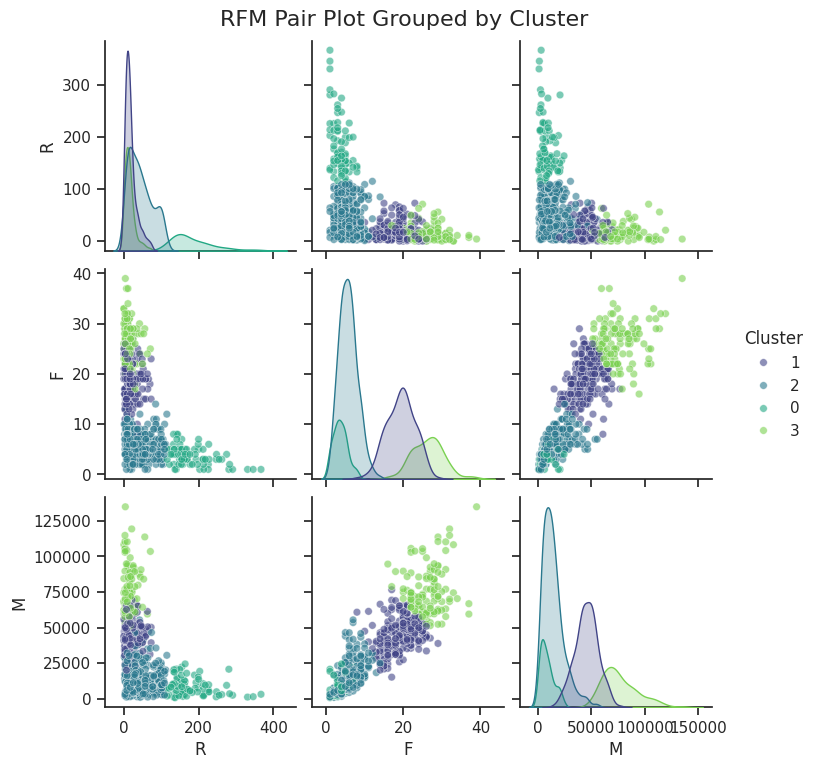

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# 設定繪圖風格
sns.set_theme(style="ticks")

# 繪製 Pair Plot，指定 R、F、M 作為特徵，並以 Cluster 作為分類顏色 (hue)
# 由於 Cluster 為類別型資料，將其轉換為字串或類別格式以獲得更佳的離散著色效果
df_plot = df.copy()
df_plot['Cluster'] = df_plot['Cluster'].astype(str)

g = sns.pairplot(
    df_plot,
    vars=['R', 'F', 'M'],
    hue='Cluster',
    palette='viridis',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30}
)

# 加入標題
g.fig.suptitle('RFM Pair Plot Grouped by Cluster', y=1.02, fontsize=16)
plt.show()

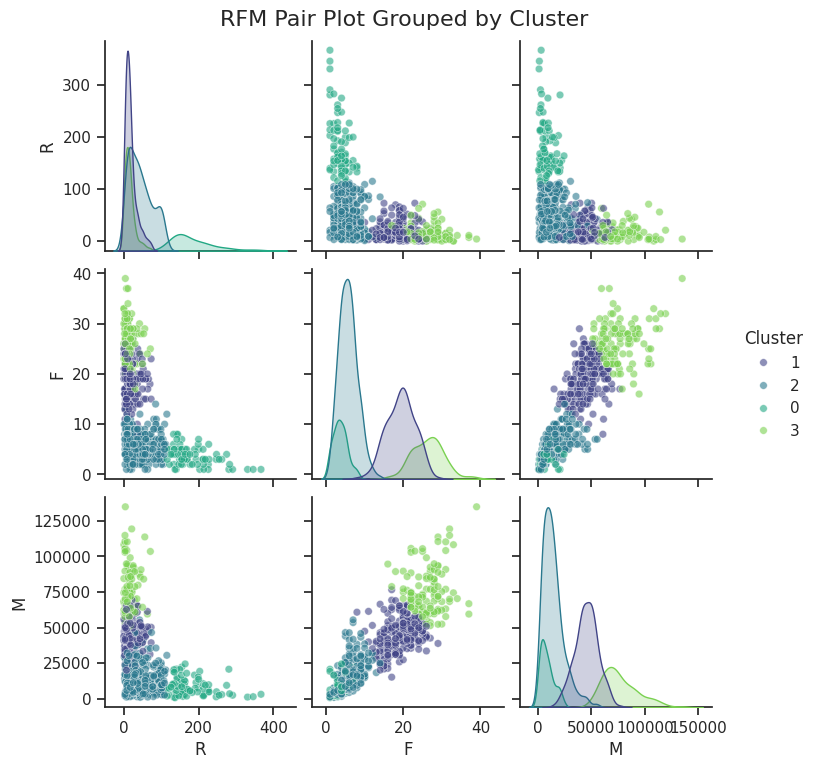

已成功儲存透明圖檔為 RFM_Pairplot.png！


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# 設定繪圖風格
sns.set_theme(style="ticks")

# 複製資料並將 Cluster 轉為字串格式
df_plot = df.copy()
df_plot['Cluster'] = df_plot['Cluster'].astype(str)

# 繪製 Pair Plot
g = sns.pairplot(
    df_plot,
    vars=['R', 'F', 'M'],
    hue='Cluster',
    palette='viridis',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30}
)

# 加入標題
g.fig.suptitle('RFM Pair Plot Grouped by Cluster', y=1.02, fontsize=16)

# 儲存為透明背景的 PNG 圖片
plt.savefig('RFM_Pairplot.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()
print("已成功儲存透明圖檔為 RFM_Pairplot.png！")

In [25]:
# 將 df 匯出成 CSV 檔案
df.to_csv('RFM_result.csv', index=False)
print("已成功將資料匯出並儲存為 RFM_result.csv！")

已成功將資料匯出並儲存為 RFM_result.csv！


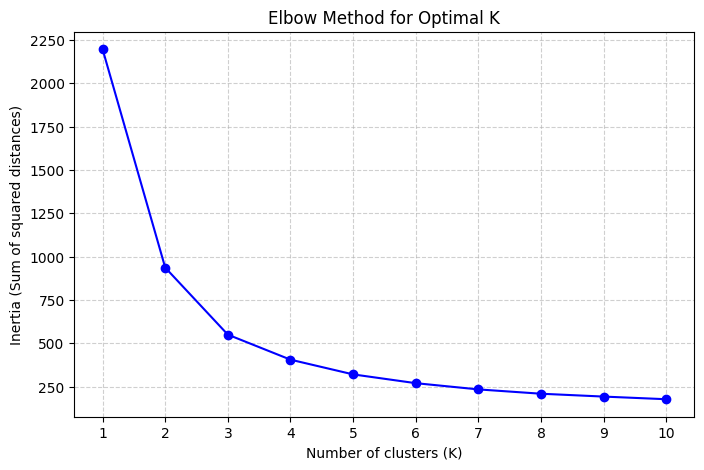

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 提取進行分群的特徵欄位 (R, F, M)
X = rfmn[['R', 'F', 'M']]

# 計算不同 K 值的群內誤差平方和 (SSE / Inertia)
sq_distances = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    sq_distances.append(kmeans.inertia_)

# 繪製手肘圖 (Elbow Chart)
plt.figure(figsize=(8, 5))
plt.plot(k_range, sq_distances, marker='o', linestyle='-', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (Sum of squared distances)')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()